# Inadimplência de clientes de cartão de crédito — Estatística Computacional

**Notebook 01 · Descrição do problema, dos dados e análise univariada**

Este notebook cobre dois pontos do trabalho:

- **1.0** — descrição do problema, dos dados, das variáveis e da natureza de cada uma;
- **1.1** — análise univariada, com distribuição de frequências de uma variável qualitativa (`EDUCATION`) e de uma quantitativa (`LIMIT_BAL`).
- **1.2.** -  Uma seção sobre gráficos univariados para ao menos uma variável de cada tipo (qualitativa nominal, qualitativa  ordinal, quantitativa discreta, quantitativa contínua);

**Fonte dos dados:** *Default of Credit Card Clients Dataset* (UCI Machine Learning Repository, disponibilizado no Kaggle por `uciml`). Referência original: Yeh, I. C.; Lien, C. H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications, 36(2), 2473–2480.

In [3]:
%pip install pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.7 MB 19.8 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 17.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------- ----------------- 5.2/9.3 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 21.5 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 20.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? e


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\izani\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
 
pd.set_option("display.float_format", "{:.2f}".format)

# 1.0 Descrição do problema, dos dados e das variáveis

- **Problema.** Instituições financeiras precisam saber quais clientes têm maior risco de não pagar a fatura do cartão de crédito (inadimplência). Neste trabalho, o objetivo é conhecer o perfil dos clientes e o comportamento de pagamento deles. 
- **Dados.** Cada linha é um cliente de cartão de crédito de um banco de Taiwan, com informações de abril a setembro de 2005. A variável de interesse é `default.payment.next.month`, que indica se o cliente deixou de pagar no mês seguinte.
- **Variáveis e sua natureza:**

 | Variável | Descrição | Natureza |
 |---|---|---|
 | `ID` | Identificador do cliente | Identificador |
 | `LIMIT_BAL` | Limite de crédito (em dólares taiwaneses) | Quantitativa contínua |
 | `SEX` | Sexo (1 = masculino, 2 = feminino) | Qualitativa nominal |
 | `EDUCATION` | Escolaridade (1 = pós-graduação, 2 = graduação, 3 = ensino médio, 4 = outros) | Qualitativa ordinal |
 | `MARRIAGE` | Estado civil (1 = casado, 2 = solteiro, 3 = outros) | Qualitativa nominal |
 | `AGE` | Idade em anos | Quantitativa discreta |
 | `PAY_0`, `PAY_2` a `PAY_6` | Situação do pagamento em setembro (`PAY_0`) até abril (`PAY_6`): -2 = sem consumo, -1 = pago em dia, 0 = crédito rotativo, 1 a 8 = meses de atraso | Qualitativa ordinal |
 | `BILL_AMT1` a `BILL_AMT6` | Valor da fatura de cada mês | Quantitativa contínua |
 | `PAY_AMT1` a `PAY_AMT6` | Valor pago em cada mês | Quantitativa contínua |
 | `default.payment.next.month` | Inadimplência no mês seguinte (1 = sim, 0 = não) | Qualitativa nominal (binária) |

In [5]:
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv")
 
print("Linhas e colunas:", df.shape)
print("Valores ausentes:", df.isna().sum().sum())
print(df.head())
 
df.info()

Linhas e colunas: (30000, 25)
Valores ausentes: 0
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1   20000.00    2          2         1   24      2      2     -1     -1   
1   2  120000.00    2          2         2   26     -1      2      0      0   
2   3   90000.00    2          2         2   34      0      0      0      0   
3   4   50000.00    2          2         1   37      0      0      0      0   
4   5   50000.00    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...       0.00       0.00       0.00      0.00    689.00      0.00   
1  ...    3272.00    3455.00    3261.00      0.00   1000.00   1000.00   
2  ...   14331.00   14948.00   15549.00   1518.00   1500.00   1000.00   
3  ...   28314.00   28959.00   29547.00   2000.00   2019.00   1200.00   
4  ...   20940.00   19146.00   19131.00   2000.00  36681.00  10000.00   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  def

# Rótulos das Categorias 

In [6]:
df["SEXO"] = df["SEX"].map({1: "Masculino", 2: "Feminino"})
 
df["ESCOLARIDADE"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["ESCOLARIDADE"] = df["ESCOLARIDADE"].map({3: "Ensino médio", 2: "Graduação", 1: "Pós-graduação", 4: "Outros"})
 
df["INADIMPLENTE"] = df["default.payment.next.month"].map({0: "Não", 1: "Sim"})
 
# Número de meses com atraso (variável quantitativa discreta)
colunas_pay = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df["N_ATRASOS"] = (df[colunas_pay] > 0).sum(axis=1)
 
print(df[["SEXO", "ESCOLARIDADE", "INADIMPLENTE", "N_ATRASOS"]].head())
 

        SEXO ESCOLARIDADE INADIMPLENTE  N_ATRASOS
0   Feminino    Graduação          Sim          2
1   Feminino    Graduação          Sim          2
2   Feminino    Graduação          Não          0
3   Feminino    Graduação          Não          0
4  Masculino    Graduação          Não          0


# 1.1 Análise univariada: distribuições de frequência
- Variável qualitativa: escolaridade (ordinal)

In [7]:
ordem = ["Ensino médio", "Graduação", "Pós-graduação", "Outros"]
 
freq_esc = df["ESCOLARIDADE"].value_counts().reindex(ordem)
tabela_esc = pd.DataFrame({
    "Frequência": freq_esc,
    "Frequência relativa (%)": freq_esc / len(df) * 100,
})
tabela_esc["Frequência acumulada (%)"] = tabela_esc["Frequência relativa (%)"].cumsum()
print(tabela_esc)

               Frequência  Frequência relativa (%)  Frequência acumulada (%)
ESCOLARIDADE                                                                
Ensino médio         4917                    16.39                     16.39
Graduação           14030                    46.77                     63.16
Pós-graduação       10585                    35.28                     98.44
Outros                468                     1.56                    100.00


A maior parte dos clientes tem graduação (46,8%), seguida por pós-graduação (35,3%) e ensino médio (16,4%). A categoria "Outros" é muito pequena, com apenas 1,6% dos clientes. Somando graduação e pós-graduação, 82,1% dos clientes têm ensino superior, o que mostra uma carteira de clientes com escolaridade relativamente alta.

- Variável quantitativa contínua: limite de crédito (em classes)


In [13]:
classes_limite = pd.cut(df["LIMIT_BAL"], bins=[0, 50000, 100000, 200000, 300000, 500000, 1000000])
 
freq_limite = classes_limite.value_counts().sort_index()
tabela_limite = pd.DataFrame({
    "Frequência": freq_limite,
    "Frequência relativa (%)": freq_limite / len(df) * 100,
})
tabela_limite["Frequência acumulada (%)"] = tabela_limite["Frequência relativa (%)"].cumsum()
print(tabela_limite)
 
print(df["LIMIT_BAL"].describe())
 

                   Frequência  Frequência relativa (%)  \
LIMIT_BAL                                                
(0, 50000]               7676                    25.59   
(50000, 100000]          4822                    16.07   
(100000, 200000]         7880                    26.27   
(200000, 300000]         5059                    16.86   
(300000, 500000]         4357                    14.52   
(500000, 1000000]         206                     0.69   

                   Frequência acumulada (%)  
LIMIT_BAL                                    
(0, 50000]                            25.59  
(50000, 100000]                       41.66  
(100000, 200000]                      67.93  
(200000, 300000]                      84.79  
(300000, 500000]                      99.31  
(500000, 1000000]                    100.00  
count     30000.00
mean     167484.32
std      129747.66
min       10000.00
25%       50000.00
50%      140000.00
75%      240000.00
max     1000000.00
Name: LIMIT_BAL

O limite de crédito médio é de aproximadamente 167.484, mas a mediana é de 140.000, ou seja, metade dos clientes tem limite de até 140.000. O desvio padrão (cerca de 129.748) é alto, indicando grande variação entre os clientes. O limite varia de 10.000 a 1.000.000. A maior parte dos clientes está concentrada em limites menores: 25,6% têm até 50.000 e 68,0% têm até 200.000. Apenas 0,7% tem limite acima de 500.000.

# 1.2 Gráficos univariados

- Qualitativa nominal: sexo

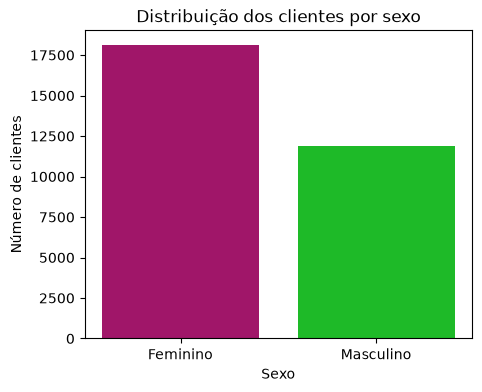

In [9]:
freq_sexo = df["SEXO"].value_counts()
 
plt.figure(figsize=(5, 4))
plt.bar(freq_sexo.index, freq_sexo.values, color=["#A01669", "#1EBA28"])
plt.title("Distribuição dos clientes por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de clientes")
plt.show()


O gráfico de barras mostra que há mais mulheres (18.112 clientes, 60,4%) do que homens (11.888 clientes, 39,6%) na carteira. Como o sexo é uma variável nominal, a ordem das barras não tem significado, e aqui elas estão ordenadas da maior para a menor.

- Qualitativa ordinal: situação do pagamento em setembro (`PAY_0`)

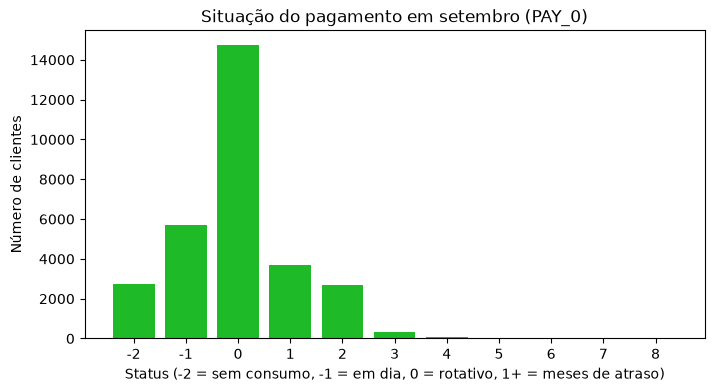

In [10]:
freq_pay0 = df["PAY_0"].value_counts().sort_index()
 
plt.figure(figsize=(8, 4))
plt.bar(freq_pay0.index.astype(str), freq_pay0.values, color="#1EBA28")
plt.title("Situação do pagamento em setembro (PAY_0)")
plt.xlabel("Status (-2 = sem consumo, -1 = em dia, 0 = rotativo, 1+ = meses de atraso)")
plt.ylabel("Número de clientes")
plt.show()

A categoria mais frequente é 0 (uso do crédito rotativo), com 49,1% dos clientes, seguida do pagamento em dia (-1), com 19,0%, e dos clientes sem consumo no mês (-2), com 9,2%. Cerca de 22,7% dos clientes estavam com algum atraso em setembro, sendo que o atraso de 1 mês (12,3%) e o de 2 meses (8,9%) concentram quase todos esses casos. .

- Quantitativa discreta: número de meses com atraso (`N_ATRASOS`)

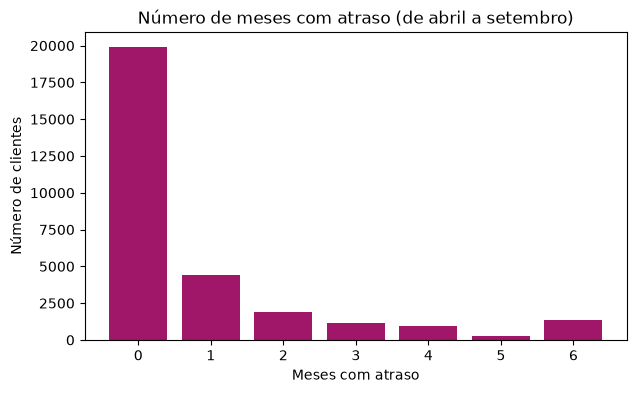

Média: 0.8342
Mediana: 0.0


In [11]:
freq_atrasos = df["N_ATRASOS"].value_counts().sort_index()
 
plt.figure(figsize=(7, 4))
plt.bar(freq_atrasos.index, freq_atrasos.values, color="#A01669")
plt.title("Número de meses com atraso (de abril a setembro)")
plt.xlabel("Meses com atraso")
plt.ylabel("Número de clientes")
plt.show()
 
print("Média:", df["N_ATRASOS"].mean())
print("Mediana:", df["N_ATRASOS"].median())

A grande maioria dos clientes (66,4%) não teve nenhum mês de atraso no período, e 14,8% tiveram atraso em apenas um mês. A frequência cai conforme o número de atrasos aumenta, mas há uma pequena alta no valor 6: 4,5% dos clientes ficaram em atraso nos seis meses, formando um grupo de devedores crônicos. A média é de 0,83 mês com atraso e a mediana é 0, o que confirma que a distribuição é assimétrica à direita.


- Quantitativa contínua: limite de crédito (`LIMIT_BAL`)

C:\Users\izani\AppData\Local\Temp\ipykernel_14004\575665192.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df["LIMIT_BAL"], vert=False)


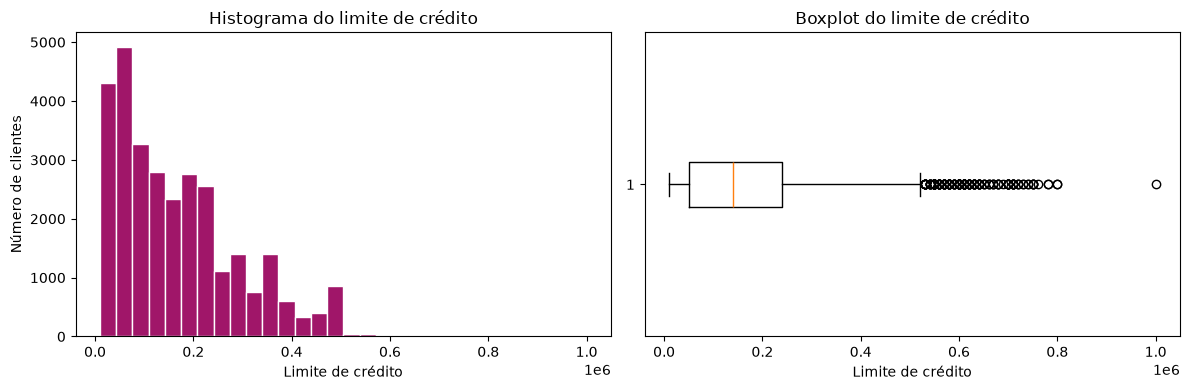

Limite superior do boxplot: 525000.0
Clientes acima do limite superior: 167
Assimetria: 0.9928669605195444


In [12]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
 
eixos[0].hist(df["LIMIT_BAL"], bins=30, color="#A01669", edgecolor="white")
eixos[0].set_title("Histograma do limite de crédito")
eixos[0].set_xlabel("Limite de crédito")
eixos[0].set_ylabel("Número de clientes")
 
eixos[1].boxplot(df["LIMIT_BAL"], vert=False)
eixos[1].set_title("Boxplot do limite de crédito")
eixos[1].set_xlabel("Limite de crédito")
 
plt.tight_layout()
plt.show()
 
# Valores extremos pelo critério do boxplot 
q1 = df["LIMIT_BAL"].quantile(0.25)
q3 = df["LIMIT_BAL"].quantile(0.75)
limite_superior = q3 + 1.5 * (q3 - q1)
 
print("Limite superior do boxplot:", limite_superior)
print("Clientes acima do limite superior:", (df["LIMIT_BAL"] > limite_superior).sum())
print("Assimetria:", df["LIMIT_BAL"].skew())

O histograma mostra uma distribuição assimétrica à direita (coeficiente de assimetria de aproximadamente 0,99): muitos clientes com limites baixos e médios e poucos com limites muito altos. O primeiro quartil é 50.000, a mediana é 140.000 e o terceiro quartil é 240.000. No boxplot, o limite superior é de 525.000, e 167 clientes ficam acima desse valor, sendo considerados valores extremos. 